<a class="cbe-colab-launch" href="https://colab.research.google.com/github/tlliuca/AI4ChemEng/blob/main/dsmles/optional/symbolic-regression.ipynb" target="_blank" rel="noopener noreferrer" title="Open this notebook in Google Colab (opens in a new tab)">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab" width="146" height="25">
</a>

In [ ]:
# Run this cell first in a fresh notebook environment.
%pip install -q "numpy<2.4" pandas matplotlib scikit-learn pycse shap xgboost umap-learn jupyterquiz==2.9.6.2 uncertainties pysr

In [ ]:
# Included CBE 4427 data; no original-course server is contacted.
from pathlib import Path
import base64, json, tempfile, zlib
_course_embedded = json.loads(zlib.decompress(base64.b64decode('eNq1WduOE0cQ/ZWOn0DxLoTHSFEEi0KQAkEEiQccRe2ZsqezPd1DX3wB8e851T03ry/LOrsvGDzjutepU8XXiW2CskbqJ5+j+vKF/BO/redWq+LC0dKR93h6wc8u//XWTH4Wk08zI8RX/kOI2eRzJM8SZng0m3ysZBClJS86MWIQIxpny1iQkF6o4IWNoYnh19lk2gkL24ayoDrqoBpN/xSVVQWN3pHGr8l5fu1T/o6tab/OP34u5loW1xdzuxGGopMaH2Ft3bWobUka0vBWYZ2jIvBPFlJ74u8WROUcP81yXpv2nUvxdkeMF9LRSEmS6sW6InwdKhLKBHKIqlhEU3B4hPIimmtj1+ZS/HUgNr6hQi1UIbXeCqlqL4IVcmVVCYHKX84m36ZH3H3NyhpHQc41iVrCAPzBogR9jpLV+z2Xg4sHPL7KL/xw0MRS+cKuEHtBmwbPVDiiTGh1TWIrfhHPNrP49On8mfhReGUebR5PESRVVCl+VaylQZnJMhkuTZnj1rlyyucrHT1eRSl5tTQ1GdTTwjpRyiBFYyHHn5HlQ1LZ0lypqNiFKPIryiyF1EvrVKhqPxXGhkMlf8qF30iGCOGqbqwL0qAxnDTXkHyO6R8rhRge6rpCGvxzRchQjv1KOsXx9Zw++DJN3dg4VUu3bX3ler0ly+xbdu1v/sh+nsKFwtaQLDPeiJpCZUs0RUlOKzbG+oMxHMX5AbDilZOlQqJFSb7gTwbEWn2R2fg75+GYPDhYWBOUiTYi2NJJBIB7aY5gI0WpgEg65IcBhHsNbYCMNhKFgcLr4i48WrfgyjkJCq8IWIU4AnOX0FWjrO6KAQdECFpZvYIvjW2ibrt9ZBw6IXp+r24Tnbq6cNZ7Rg7GtJGTvW8Nnqt98No0bQmc9PQFLIeJjVyem7MbEhJWeyrZ2uCkMjeGSNvueNoh4lC2O91xzOI3KAQSV9JphEPW6LIDyfnelh8Lyz3lU8vPKTsB88clPRXLA2mFxykhgKFSulLIBk8l0sSYegTXvr/3GXSgQYprwmwrV9IEuUyJP9TuKaA3Iv4Ajf8msnsy4X3KMscBcaIzMnFoWrLDaNM0z72261z9uZ5CJfeKCgkrJDIGMG57hDhkK8mouNco31VnL4jhHX0ErY3VQ0M21danFhvNW6VV2N4VIl62DYA6G6Y/V9+gEzyJthZK+yCnGZ3McHalShqbg7lbBYCISRTiGI076fXvEMEzvCjwkwIDjSeIZmUIXO3vgfyxg2gOhaEqqn1tPOc0bXqNU+TbxmV1dDoD8DIi1qnfut+JNYZeOyC3CVTH6NiPgVOxeI+sKKgSmPY+Bf4M919yvlyWlDlRSQ0hf9Yk1Gjt7fxGGbUAiWfdlAcS3ZkvtKD0DgwMnbNwADqhskoepSixIxDyAGjxgdGRksLdOs5cM6cq1QLaFQ1Vqkz7yTnrzqm5Dzc9d7RgujCaOuOmyxEfWXSqKlg2vCjpwi7AaKNbcZOGNZEZaEZf0WmC96m9K0Ls+eEru/YjtAic6kSyeUqhsHvLvLgQWxs7dgSeDLygwTCOuWWqakCVZKId4xJku1dItOCVRd4Wj7mNPPq2fSA4wgsVQmL6piWq7RdnD2tHjIiJWaSdETWlqchzea/Wd1bCudS8IvjB/ZW/HLI1OH6bo7XcqDrWwsR6DuDigiYHsIEWDKnEF+RQBmdVLhp3baMumYNI7lWfeiaIR1DuwYUfDwCx4/F6oApts3VF4a2OZ2wdLA6DtM580iyVoXZ3a3i36enemrS+8FFxbo5QngcAldc106BC87q56KyB06jmIsAKTqo1dN4ue1C46+ZBkzY//qKwS6PSwzljF5hJqRGF+fYw6+0rrkOhkwXX8QMOuWMuoOU6L+rJR5aDhZfp6J0vFO9vCkDkAvp2YbmQd2floPpR4hXPnavIqDjCIZRkLXn5PjilwVL4mMMHhpFHO9eKzo72GHQqKm958Yc8dPQycpYAbAVrgkykX8s5dPNR4Cyy8sc7EaQHTWmTPajJlp11rHhuLNpwi8kfqD1oYRMl43Mqy/91tehYLWP2nhomxonGjiozIaPUQJKy23kOk3DaFHyYw4RZKMNGDlwz2aDPPGW01KRmMo+KuHWn4U6WLgP/w682V3lg5oCJThQyxoed/vpzT3sOE9hbNE354stz32SetPkpTdTNs47O8QzkUxhteBs+fdj4q92lxiubKCMNt4V0p+ivJbw63cflo46+v9C0axmyOldGAqoVj6jjS1qPLb3VNW+f3VrI2+CyvRtdzCVv7TfO1uMN/lRw/jRonrykpEhrYJJ0oi/0SjX3mff+/mGsaVV1B2/PtEzH3HPsJq9BTi0tOpzwl2J4M1M12uRZh1CezH9b3N15I8+S8X8xnLvlHVnid1hYSXwYPq4WjLUj/4mN9ge/7oIMnlPn9tgDnZnB5+Tbf0bo+7k=')))
_course_cache = Path(tempfile.mkdtemp(prefix="cbe4427-"))
def course_file(name):
    """Use a local course file, or the copy embedded in this notebook."""
    for root in [Path.cwd(), *Path.cwd().parents]:
        for candidate in [root / "dsmles" / name, root / name]:
            if candidate.is_file():
                return str(candidate)
    if name not in _course_embedded:
        raise FileNotFoundError("Course resource not included: " + name)
    target = (_course_cache / name).resolve()
    if _course_cache not in target.parents:
        raise ValueError("Invalid course resource path")
    target.parent.mkdir(parents=True, exist_ok=True)
    if not target.exists():
        target.write_text(_course_embedded[name])
    return str(target)


# Optional: Symbolic Regression

Discovering equations from data.

## Learning Objectives

1. Understand symbolic regression vs standard ML
2. Use PySR for equation discovery
3. Balance accuracy and complexity
4. Interpret discovered equations

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Note: PySR must be installed separately
# pip install pysr
try:
    from pysr import PySRRegressor
    PYSR_AVAILABLE = True
except ImportError:
    print("PySR not installed. Run: pip install pysr")
    PYSR_AVAILABLE = False

PySR not installed. Run: pip install pysr


## Symbolic Regression

Unlike black-box ML, symbolic regression finds **interpretable equations**:

- Black-box ML: $y = f(x)$ (unknown function)
- Symbolic regression: $y = 2x^2 + \sin(x)$ (explicit equation)

Uses genetic programming to evolve equations.

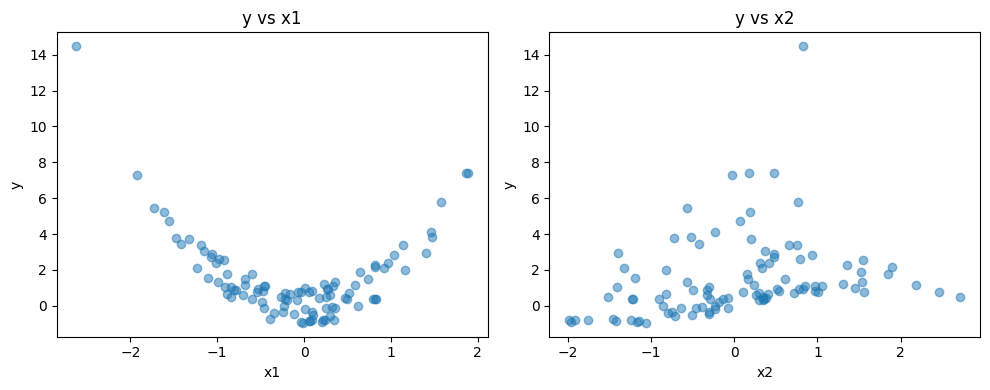

In [2]:
# Create data from a known equation
np.random.seed(42)

# True relationship: y = 2*x1^2 + sin(x2)
X = np.random.randn(100, 2)
y = 2*X[:, 0]**2 + np.sin(X[:, 1]) + np.random.normal(0, 0.1, 100)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], y, alpha=0.5)
plt.xlabel('x1')
plt.ylabel('y')
plt.title('y vs x1')

plt.subplot(1, 2, 2)
plt.scatter(X[:, 1], y, alpha=0.5)
plt.xlabel('x2')
plt.ylabel('y')
plt.title('y vs x2')

plt.tight_layout()
plt.show()

In [3]:
if PYSR_AVAILABLE:
    # Run symbolic regression
    model = PySRRegressor(
        niterations=100,
        binary_operators=["+", "-", "*", "/"],
        unary_operators=["sin", "cos", "exp", "log", "square"],
        maxsize=20,
        verbosity=0
    )
    
    model.fit(X, y)
    
    print("Discovered equations (Pareto front):")
    print(model)

In [4]:
if PYSR_AVAILABLE:
    # Get the best equation
    print(f"\nBest equation: {model.sympy()}")
    print(f"R² Score: {model.score(X, y):.4f}")
    
    # Visualize fit
    y_pred = model.predict(X)
    
    plt.figure(figsize=(8, 8))
    plt.scatter(y, y_pred, alpha=0.5)
    plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title(f'Symbolic Regression: {model.sympy()}')
    plt.grid(True, alpha=0.3)
    plt.show()

## Knowledge Check

In [ ]:
%pip install -q jupyterquiz
from jupyterquiz import display_quiz

display_quiz(course_file('optional/quizzes/symbolic-regression-quiz.json'))

<IPython.core.display.Javascript object>

## Applications in Chemical Engineering

- **Kinetic models**: Discover rate laws from data
- **Thermodynamic correlations**: Find equations of state
- **Transport properties**: Develop viscosity correlations
- **Process optimization**: Interpretable surrogate models

## Comparison

| Aspect | Neural Networks | Symbolic Regression |
|--------|-----------------|--------------------|
| Accuracy | High | Moderate-High |
| Interpretability | Low | High |
| Extrapolation | Poor | Better |
| Training time | Fast | Slow |
| Physical insight | None | Yes |